In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# === 设置路径 ===
calib_dir = r"E:\graduate_design\test4\tmp\test_sequence4\config"
image1_path = r"E:\graduate_design\test\input\cam0\D02_20240829012415_second_0000.jpg"
image2_path = r"E:\graduate_design\test\input\cam1\D01_20240829012103_second_0192.jpg"
out_dir = r"E:\graduate_design\test7\0820"
os.makedirs(out_dir, exist_ok=True)

# === 加载相机参数 ===
def load_camera_calibration(intrinsic_path, distortion_path):
    """ 加载相机内参和畸变参数 """
    fs_intr = cv2.FileStorage(intrinsic_path, cv2.FILE_STORAGE_READ)
    fs_dist = cv2.FileStorage(distortion_path, cv2.FILE_STORAGE_READ)
    
    intr = fs_intr.getNode("intrinsics_penne").mat()
    dist = fs_dist.getNode("intrinsics_penne").mat()

    fs_intr.release()
    fs_dist.release()

    if intr is None or dist is None:
        raise ValueError(f"❌ 失败: 无法加载 {intrinsic_path} 或 {distortion_path}")

    return intr, dist

# 读取校准参数
intr1, dist1 = load_camera_calibration(
    os.path.join(calib_dir, "intrinsics_00.xml"),
    os.path.join(calib_dir, "distortion_00.xml")
)
intr2, dist2 = load_camera_calibration(
    os.path.join(calib_dir, "intrinsics_01.xml"),
    os.path.join(calib_dir, "distortion_01.xml")
)

# === 处理图像：去畸变 ===
def process_image(image_path, intr, dist, output_name):
    """ 读取图像并进行去畸变 """
    print(f"📷 处理图像: {image_path}")
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"❌ 失败: 无法加载 {image_path}")

    # CLAHE 直方图均衡
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = clahe.apply(image)

    # 去畸变
    undistorted = cv2.undistort(image, intr, dist)

    # 保存去畸变图像
    output_path = os.path.join(out_dir, output_name)
    cv2.imwrite(output_path, undistorted)
    print(f"✅ 处理完成，保存至 {output_path}")
    
    return undistorted

img1 = process_image(image1_path, intr1, dist1, "undistorted_1.jpg")
img2 = process_image(image2_path, intr2, dist2, "undistorted_2.jpg")


D:\py\Anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


📷 处理图像: E:\graduate_design\test\input\cam0\D02_20240829012415_second_0000.jpg
✅ 处理完成，保存至 E:\graduate_design\test7\0820\undistorted_1.jpg
📷 处理图像: E:\graduate_design\test\input\cam1\D01_20240829012103_second_0192.jpg
✅ 处理完成，保存至 E:\graduate_design\test7\0820\undistorted_2.jpg


✅ 保留 1269 组特征匹配点


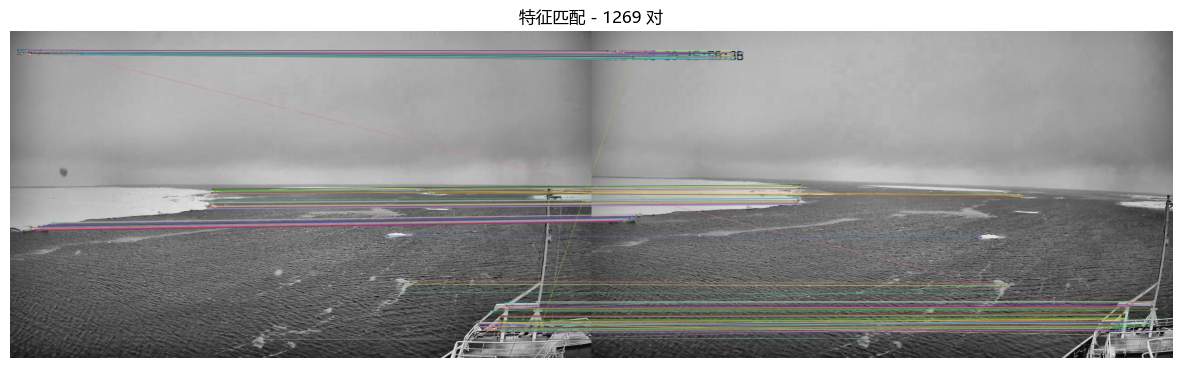

In [37]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# === 设置路径 ===
out_dir = r"E:\graduate_design\test7\0820"
img1_path = os.path.join(out_dir, "undistorted_1.jpg")
img2_path = os.path.join(out_dir, "undistorted_2.jpg")
match_file = os.path.join(out_dir, "matches.txt")

# === 读取图像 ===
img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)
assert img1 is not None and img2 is not None, "❌ 失败: 图像加载错误"

# === 关键点检测与匹配 + 二级筛选 ===
def detect_and_match_features(img1, img2):
    orb = cv2.ORB_create(5000)
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)
    if des1 is None or des2 is None:
        return [], [], []
    
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # --- 基于邻域一致性进一步筛选 ---
    good_matches = []
    if len(matches) >= 10:
        pts1 = np.array([kp1[m.queryIdx].pt for m in matches])
        nbrs = NearestNeighbors(n_neighbors=10, algorithm='auto').fit(pts1)
        distances, _ = nbrs.kneighbors(pts1)
        local_density = distances[:, 1:].mean(axis=1)  # 跳过第一个自身
        threshold = np.percentile(local_density, 80)   # 保留局部密集的20%
        for i, m in enumerate(matches):
            if local_density[i] < threshold:
                good_matches.append(m)
    else:
        good_matches = matches  # 匹配点太少时保留全部
    
    return kp1, kp2, good_matches

def save_matches(file_path, kp1, kp2, matches):
    with open(file_path, "w") as f:
        for match in matches:
            x1, y1 = kp1[match.queryIdx].pt
            x2, y2 = kp2[match.trainIdx].pt
            f.write(f"{x1} {y1} {x2} {y2}\n")

kp1, kp2, matches = detect_and_match_features(img1, img2)

if len(matches) == 0:
    print("⚠️ 没有找到有效匹配")
else:
    print(f"✅ 保留 {len(matches)} 组特征匹配点")
    save_matches(match_file, kp1, kp2, matches)

# 绘制匹配图
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:500], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(15, 6))
plt.imshow(img_matches)
plt.title(f"特征匹配 - {len(matches)} 对")
plt.axis("off")
plt.show()


In [38]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# === 设置路径 ===
out_dir = r"E:\graduate_design\test7\0820"
match_file = os.path.join(out_dir, "matches.txt")

# === 读取匹配点 ===
def load_matches(file_path):
    """ 从文本文件加载匹配点 """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"❌ 失败: 匹配文件 {file_path} 不存在，请检查路径！")

    pts1, pts2 = [], []
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("#") or len(line) == 0:  # 忽略注释或空行
                continue
            try:
                x1, y1, x2, y2 = map(float, line.split())
                pts1.append([x1, y1])
                pts2.append([x2, y2])
            except ValueError:
                print(f"⚠️ 忽略格式错误的行: {line}")

    if len(pts1) < 8:
        raise ValueError("❌ 失败: 匹配点太少，至少需要 8 对匹配点！")

    return np.array(pts1), np.array(pts2)

# 读取匹配点
pts1, pts2 = load_matches(match_file)

# === 计算本质矩阵 ===
def estimate_essential_matrix(pts1, pts2, K):
    """ 估算本质矩阵 """
    E, mask = cv2.findEssentialMat(pts1, pts2, K, method=cv2.RANSAC, prob=0.999, threshold=1.5)
    return E, mask

# 假设相机内参矩阵 (K)
K = np.array([[1000, 0, 640],
              [0, 1000, 360],
              [0, 0, 1]], dtype=np.float64)

E, mask = estimate_essential_matrix(pts1, pts2, K)

# === 分解本质矩阵 ===
def decompose_essential_matrix(E):
    """ 分解本质矩阵，获得 4 种旋转和平移组合 """
    R1, R2, t = cv2.decomposeEssentialMat(E)
    return [(R1, t), (R1, -t), (R2, t), (R2, -t)]

candidates = decompose_essential_matrix(E)

# === 选择最优 R 和 T ===
def triangulate_points(R, T, K, pts1, pts2):
    """ 使用三角测量检查 R, T 是否正确 """
    proj_mat1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))
    proj_mat2 = K @ np.hstack((R, T))

    pts1_h = cv2.convertPointsToHomogeneous(pts1)[:, 0, :]
    pts2_h = cv2.convertPointsToHomogeneous(pts2)[:, 0, :]

    points_4d_hom = cv2.triangulatePoints(proj_mat1, proj_mat2, pts1_h.T[:2], pts2_h.T[:2])
    points_3d = points_4d_hom[:3] / points_4d_hom[3]

    # 只选择 Z > 0 的情况
    valid_count = np.sum(points_3d[2] > 0)
    return valid_count, points_3d.T

best_valid = 0
best_R, best_T, best_3d_points = None, None, None

for R, T in candidates:
    valid_count, points_3d = triangulate_points(R, T, K, pts1, pts2)
    if valid_count > best_valid:
        best_valid = valid_count
        best_R, best_T = R, T
        best_3d_points = points_3d

print(f"✅ 选定 R: \n{best_R}")
print(f"✅ 选定 T: \n{best_T.T}")

# === 计算极线误差 ===
def compute_epipolar_error(F, pts1, pts2):
    """ 计算极线误差 """
    pts1_h = np.hstack((pts1, np.ones((pts1.shape[0], 1))))
    pts2_h = np.hstack((pts2, np.ones((pts2.shape[0], 1))))

    error = np.abs(np.sum(pts2_h * (F @ pts1_h.T).T, axis=1))
    return np.mean(error)

F = np.linalg.inv(K.T) @ E @ np.linalg.inv(K)
epi_error = compute_epipolar_error(F, pts1, pts2)
print(f"📏 初始极线误差: {epi_error:.4f} px")

# === 使用 Bundle Adjustment (SBA) 优化 ===
def bundle_adjustment(R, T, points_3d, pts2, K):
    """使用第二幅图像的2D点和三角化的3D点做优化"""

    points_3d = points_3d.astype(np.float64)
    pts2 = pts2.astype(np.float64)

    def reprojection_error(params, points_3d, pts2, K):
        rvec, tvec = params[:3], params[3:]
        R_opt, _ = cv2.Rodrigues(rvec)

        points_2d, _ = cv2.projectPoints(points_3d, rvec, tvec, K, None)
        points_2d = points_2d.squeeze()

        if points_2d.shape[0] != pts2.shape[0]:
            raise ValueError("❌ 失败: 重投影点数量不足，可能是 projectPoints 失败！")

        error = (pts2 - points_2d).ravel()
        return error

    # 初始参数为原始 R 和 T 转换为 rvec 和 tvec
    params0 = np.hstack([cv2.Rodrigues(R)[0].ravel(), T.ravel()])

    result = least_squares(reprojection_error, params0, args=(points_3d, pts2, K))

    optimized_rvec, optimized_tvec = result.x[:3], result.x[3:]
    optimized_R, _ = cv2.Rodrigues(optimized_rvec)
    optimized_T = optimized_tvec.reshape(3, 1)

    return optimized_R, optimized_T

opt_R, opt_T = bundle_adjustment(best_R, best_T, best_3d_points, pts2, K)


print(f"🔹 优化后 R: \n{opt_R}")
print(f"🔹 优化后 T: \n{opt_T.T}")

# 计算优化后的极线误差
F_opt = np.linalg.inv(K.T) @ E @ np.linalg.inv(K)
epi_error_opt = compute_epipolar_error(F_opt, pts1, pts2)
print(f"📏 优化后极线误差: {epi_error_opt:.4f} px") 

✅ 选定 R: 
[[ 0.99968712  0.01478264 -0.02017754]
 [-0.01658092  0.99561361 -0.09207934]
 [ 0.01872786  0.09238509  0.99554722]]
✅ 选定 T: 
[[ 0.56085566  0.36293927 -0.74412097]]
📏 初始极线误差: 0.0892 px
🔹 优化后 R: 
[[ 0.99963755  0.00836091 -0.02559033]
 [-0.01044134  0.99655494 -0.08227535]
 [ 0.02481427  0.08251273  0.99628104]]
🔹 优化后 T: 
[[ 0.55762514  0.36021625 -0.74509821]]
📏 优化后极线误差: 0.0892 px


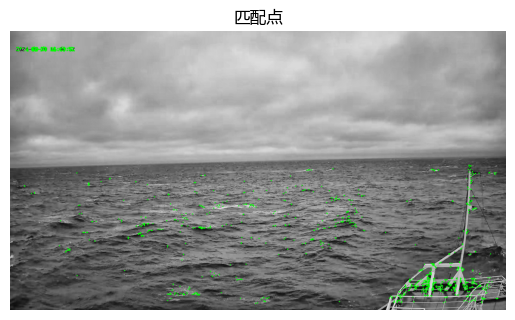

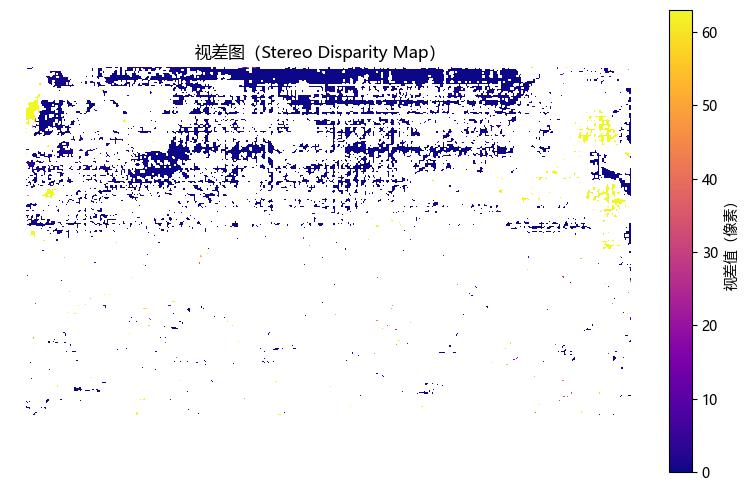

✅ 拟合平面参数 (a, b, c, d): (-0.7592104, -0.10397377, -0.64248663, -242.9336)
✅ 平面裁剪后点云保存至: E:\graduate_design\test7\0820\point_cloud_plane_filtered.ply


In [4]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.dates as mdates
# 设置中文字体和字号
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.size'] = 10  # 全局字体大小
# === 设置路径 ===
out_dir = r"E:\graduate_design\test7\0820"
match_file = os.path.join(out_dir, "matches.txt")
img1_path = os.path.join(out_dir, "undistorted_1.jpg")
img2_path = os.path.join(out_dir, "undistorted_2.jpg")

# === 读取图像 ===
img_left = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
img_right = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)
assert img_left is not None and img_right is not None, "❌ 图像加载失败"

# === 相机内参 ===
K = np.array([[1000, 0, 640],
              [0, 1000, 360],
              [0, 0, 1]], dtype=np.float64)

# === 假设 opt_R 和 opt_T 来自 autocalibrate 步骤 ===
# TODO: 替换为你真实的优化结果
opt_R = np.eye(3)
opt_T = np.array([[1], [0], [0]])
K = K.astype(np.float64)
opt_R = opt_R.astype(np.float64)
opt_T = opt_T.astype(np.float64)
if opt_T.shape == (3,):
    opt_T = opt_T.reshape((3, 1))

# === 图像大小 ===
image_size = img_left.shape[::-1]

# === 立体校正 ===
R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(K, None, K, None, image_size, opt_R, opt_T, flags=cv2.CALIB_ZERO_DISPARITY, alpha=0)
map1x, map1y = cv2.initUndistortRectifyMap(K, None, R1, P1, image_size, cv2.CV_32FC1)
map2x, map2y = cv2.initUndistortRectifyMap(K, None, R2, P2, image_size, cv2.CV_32FC1)
imgL_rect = cv2.remap(img_left, map1x, map1y, cv2.INTER_LINEAR)
imgR_rect = cv2.remap(img_right, map2x, map2y, cv2.INTER_LINEAR)

# === 匹配点可视化 ===
matches = np.loadtxt(match_file)
pts1 = matches[:, 0:2].astype(int)
pts2 = matches[:, 2:4].astype(int)
img_matches = cv2.cvtColor(imgL_rect.copy(), cv2.COLOR_GRAY2BGR)
for pt1 in pts1:
    cv2.circle(img_matches, tuple(pt1), 3, (0, 255, 0), -1)
plt.imshow(img_matches)
plt.title("匹配点")
plt.axis('off')
plt.show()

# # === 计算视差图 ===
# stereo = cv2.StereoSGBM_create(minDisparity=0,
#                                numDisparities=64,
#                                blockSize=5,
#                                P1=8 * 3 * 5**2,
#                                P2=32 * 3 * 5**2,
#                                uniquenessRatio=10,
#                                speckleWindowSize=100,
#                                speckleRange=32,
#                                disp12MaxDiff=1)
# disparity = stereo.compute(imgL_rect, imgR_rect).astype(np.float32) / 16.0
# plt.imshow(disparity, cmap='plasma')
# plt.title("视差图")
# plt.colorbar()
# # cbar = plt.colorbar(im)
# cbar.set_label('视差值（像素）', fontsize=10)
# # plt.axis('off')
# plt.show()
# === 计算视差图 ===
stereo = cv2.StereoSGBM_create(minDisparity=0,
                               numDisparities=64,
                               blockSize=5,
                               P1=8 * 3 * 5**2,
                               P2=32 * 3 * 5**2,
                               uniquenessRatio=10,
                               speckleWindowSize=100,
                               speckleRange=32,
                               disp12MaxDiff=1)
disparity = stereo.compute(imgL_rect, imgR_rect).astype(np.float32) / 16.0

# 设置 NaN 显示为黑色
disparity[disparity < 0] = np.nan

plt.figure(figsize=(10, 6))
im = plt.imshow(disparity, cmap='plasma')
plt.title("视差图（Stereo Disparity Map）", fontsize=12)
cbar = plt.colorbar(im)
cbar.set_label('视差值（像素）', fontsize=10)
plt.axis('off')
plt.show()

# === 生成点云 ===
points_3D = cv2.reprojectImageTo3D(disparity, Q)
mask = disparity > 0
points = points_3D[mask]
colors = cv2.cvtColor(imgL_rect, cv2.COLOR_GRAY2BGR)[mask]

# === 平面拟合 ===
def ransac_find_plane(points, threshold=0.02, max_iter=1000):
    best_inliers = []
    best_plane = None
    for _ in range(max_iter):
        sample = points[np.random.choice(points.shape[0], 3, replace=False)]
        v1 = sample[1] - sample[0]
        v2 = sample[2] - sample[0]
        normal = np.cross(v1, v2)
        if np.linalg.norm(normal) == 0:
            continue
        normal = normal / np.linalg.norm(normal)
        d = -np.dot(normal, sample[0])
        dist = np.abs(points @ normal + d)
        inliers = dist < threshold
        if inliers.sum() > len(best_inliers):
            best_inliers = inliers
            best_plane = (*normal, d)
    return best_plane, best_inliers

# === 平面裁剪 ===
def refine_plane(points, plane, threshold=0.02):
    normal = np.array(plane[:3])
    d = plane[3]
    dist = np.abs(points @ normal + d)
    return dist < threshold

# === 执行平面拟合与裁剪 ===
plane_params, inliers = ransac_find_plane(points)
print("✅ 拟合平面参数 (a, b, c, d):", plane_params)
refined_mask = refine_plane(points, plane_params, threshold=0.02)
filtered_points = points[refined_mask]
filtered_colors = colors[refined_mask]

# === 保存点云 ===
def save_ply(filename, verts, colors):
    verts = verts.reshape(-1, 3)
    colors = colors.reshape(-1, 3)
    with open(filename, 'w') as f:
        f.write('ply\nformat ascii 1.0\nelement vertex {}\n'.format(len(verts)))
        f.write('property float x\nproperty float y\nproperty float z\n')
        f.write('property uchar blue\nproperty uchar green\nproperty uchar red\nend_header\n')
        for v, c in zip(verts, colors):
            f.write('{} {} {} {} {} {}\n'.format(v[0], v[1], v[2], c[0], c[1], c[2]))

output_ply = os.path.join(out_dir, "point_cloud_plane_filtered.ply")
save_ply(output_ply, filtered_points, filtered_colors)
print(f"✅ 平面裁剪后点云保存至: {output_ply}")


📈 动态匹配窗口大小 blockSize=5


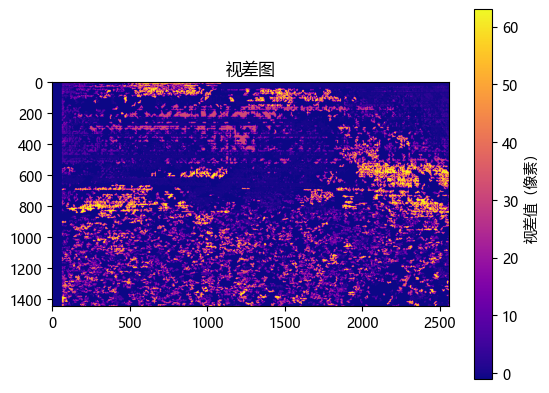

✅ 有效点数量：435
✅ 最终点云保存至: E:\graduate_design\test7\0820\point_cloud_final_filtered.ply


In [39]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
from sklearn.neighbors import NearestNeighbors

matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.size'] = 10

out_dir = r"E:\graduate_design\test7\0820"
match_file = os.path.join(out_dir, "matches.txt")
img1_path = os.path.join(out_dir, "undistorted_1.jpg")
img2_path = os.path.join(out_dir, "undistorted_2.jpg")

img_left = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
img_right = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)
assert img_left is not None and img_right is not None, "图像加载失败"

# 相机内参
K = np.array([[1000, 0, 640],
              [0, 1000, 360],
              [0, 0, 1]], dtype=np.float64)
opt_R = np.eye(3)
opt_T = np.array([[1], [0], [0]], dtype=np.float64)

image_size = img_left.shape[::-1]
R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(K, None, K, None, image_size, opt_R, opt_T, flags=cv2.CALIB_ZERO_DISPARITY, alpha=0)
map1x, map1y = cv2.initUndistortRectifyMap(K, None, R1, P1, image_size, cv2.CV_32FC1)
map2x, map2y = cv2.initUndistortRectifyMap(K, None, R2, P2, image_size, cv2.CV_32FC1)
imgL_rect = cv2.remap(img_left, map1x, map1y, cv2.INTER_LINEAR)
imgR_rect = cv2.remap(img_right, map2x, map2y, cv2.INTER_LINEAR)

# 动态自适应窗口大小 (根据局部纹理)
def adaptive_sgbm(img_left, img_right):
    img_blur = cv2.Laplacian(img_left, cv2.CV_64F).var()  # 纹理复杂度估计（Laplacian方差）
    if img_blur < 50:  # 低纹理
        block_size = 11
    elif img_blur < 150:  # 中等纹理
        block_size = 7
    else:  # 高纹理
        block_size = 5
    print(f"📈 动态匹配窗口大小 blockSize={block_size}")

    stereo = cv2.StereoSGBM_create(minDisparity=0,
                                   numDisparities=64,
                                   blockSize=block_size,
                                   P1=8 * 3 * block_size**2,
                                   P2=32 * 3 * block_size**2,
                                   uniquenessRatio=10,
                                   speckleWindowSize=100,
                                   speckleRange=32,
                                   disp12MaxDiff=1)
    disparity = stereo.compute(img_left, img_right).astype(np.float32) / 16.0
    return disparity

disparity = adaptive_sgbm(imgL_rect, imgR_rect)

plt.imshow(disparity, cmap='plasma')
plt.title("视差图")
plt.colorbar(label="视差值（像素）")
plt.show()

# 生成点云
points_3D = cv2.reprojectImageTo3D(disparity, Q)
mask = disparity > 0
points = points_3D[mask]
colors = cv2.cvtColor(imgL_rect, cv2.COLOR_GRAY2BGR)[mask]

# RANSAC平面拟合
def ransac_find_plane(points, threshold=0.02, max_iter=1000):
    best_inliers = []
    best_plane = None
    for _ in range(max_iter):
        sample = points[np.random.choice(points.shape[0], 3, replace=False)]
        v1 = sample[1] - sample[0]
        v2 = sample[2] - sample[0]
        normal = np.cross(v1, v2)
        if np.linalg.norm(normal) == 0:
            continue
        normal = normal / np.linalg.norm(normal)
        d = -np.dot(normal, sample[0])
        dist = np.abs(points @ normal + d)
        inliers = dist < threshold
        if inliers.sum() > len(best_inliers):
            best_inliers = inliers
            best_plane = (*normal, d)
    return best_plane, best_inliers

# 平面剔除背景
plane_params, inliers = ransac_find_plane(points)
refined_mask = np.abs(points @ np.array(plane_params[:3]) + plane_params[3]) < 0.02
filtered_points = points[refined_mask]
filtered_colors = colors[refined_mask]

# === Z轴三倍标准差异常点剔除 ===
z_values = filtered_points[:, 2]
mean_z = np.mean(z_values)
std_z = np.std(z_values)
z_mask = (z_values > mean_z - 3*std_z) & (z_values < mean_z + 3*std_z)

final_points = filtered_points[z_mask]
final_colors = filtered_colors[z_mask]

print(f"✅ 有效点数量：{len(final_points)}")

# 保存PLY
def save_ply(filename, verts, colors):
    verts = verts.reshape(-1, 3)
    colors = colors.reshape(-1, 3)
    with open(filename, 'w') as f:
        f.write('ply\nformat ascii 1.0\nelement vertex {}\n'.format(len(verts)))
        f.write('property float x\nproperty float y\nproperty float z\n')
        f.write('property uchar blue\nproperty uchar green\nproperty uchar red\nend_header\n')
        for v, c in zip(verts, colors):
            f.write('{} {} {} {} {} {}\n'.format(v[0], v[1], v[2], c[0], c[1], c[2]))

output_ply = os.path.join(out_dir, "point_cloud_final_filtered.ply")
save_ply(output_ply, final_points, final_colors)
print(f"✅ 最终点云保存至: {output_ply}")


In [35]:
import numpy as np
from scipy.fftpack import dct
import torch
from tqdm import tqdm

class DCTInterpolator:
    def __init__(self, img_width, img_height, alg_options):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Using {self.device} device")

        C = dct(np.eye(img_height), type=3, norm='ortho')
        self.Dc = torch.tensor(C, requires_grad=True, dtype=torch.float, device=self.device)
        self.height = img_height
        self.width = img_width
        self.Nfreqs = self._get_setting_helper(alg_options, "Nfreqs")
        self.MAX_ITERS = self._get_setting_helper(alg_options, "MAX_ITERS")
        self.TOLERANCE_CHANGE = self._get_setting_helper(alg_options, "TOLERANCE_CHANGE")
        self.REGULARIZER_ALPHA = self._get_setting_helper(alg_options, "REGULARIZER_ALPHA")
        self.LEARNING_RATE = self._get_setting_helper(alg_options, "LEARNING_RATE")

    def _get_setting_helper(self, options_dict, setting_name):
        default_settings = {
            "Nfreqs": 150,
            "MAX_ITERS": 500,
            "TOLERANCE_CHANGE": 1E-4,
            "REGULARIZER_ALPHA": 8E-7,
            "LEARNING_RATE": 5.0
        }
        return options_dict.get(setting_name, default_settings[setting_name])

    def __call__(self, I, verbose=True):
        orig_pts_mask = 1 - np.isnan(I).astype(np.uint8)
        mask = orig_pts_mask.astype(np.float32)
        I[np.isnan(I)] = 0

        Dc = self.Dc
        Iorig = torch.tensor(I, dtype=torch.float, device=self.device)
        Imask = torch.tensor(mask, dtype=torch.float, device=self.device)
        x = torch.rand((self.Nfreqs, self.Nfreqs), requires_grad=True, device=self.device)
        xprev = torch.clone(x)

        optimizer = torch.optim.Rprop([x], lr=self.LEARNING_RATE)

        for ii in range(self.MAX_ITERS + 1):
            def closure(output_all_loss_components=False):
                optimizer.zero_grad()
                full_signal = torch.nn.functional.pad(x, (0, self.height - self.Nfreqs, 0, self.width - self.Nfreqs), "constant", 0)
                Irec = Dc.T @ full_signal @ Dc
                data_loss = torch.sum(torch.square(Irec - Iorig) * Imask) / torch.sum(Imask)
                regularizer_loss = torch.linalg.vector_norm(x, ord=1)
                loss = data_loss + self.REGULARIZER_ALPHA * regularizer_loss
                loss.backward()
                if output_all_loss_components:
                    return loss, data_loss, regularizer_loss
                return loss

            optimizer.step(closure)

            if ii % 50 == 0:
                loss, data_loss, regularizer_loss = closure(output_all_loss_components=True)
                fdelta = torch.max(torch.abs(x - xprev)).item()
                if verbose:
                    tqdm.write(f"Iter {ii:05d} | Loss: {loss.item():.6f} | Δ: {fdelta:.6f}")
                if fdelta < self.TOLERANCE_CHANGE:
                    break
                xprev = torch.clone(x)

        full_signal = torch.nn.functional.pad(x, (0, self.height - self.Nfreqs, 0, self.width - self.Nfreqs), "constant", 0)
        Irec = Dc.T @ full_signal @ Dc
        return Irec.cpu().detach().numpy(), np.ones_like(mask)


✅ 加载点云: 285 个点
Using cpu device
Iter 00000 | Loss: 263823.968750 | Δ: 4.000000
Iter 00050 | Loss: 248094.375000 | Δ: 2082.783936
Iter 00100 | Loss: 231558.625000 | Δ: 2500.000244
Iter 00150 | Loss: 216015.343750 | Δ: 2500.000244
Iter 00200 | Loss: 201132.890625 | Δ: 2500.000488
Iter 00250 | Loss: 186812.421875 | Δ: 2500.000000
Iter 00300 | Loss: 173050.109375 | Δ: 2500.000000


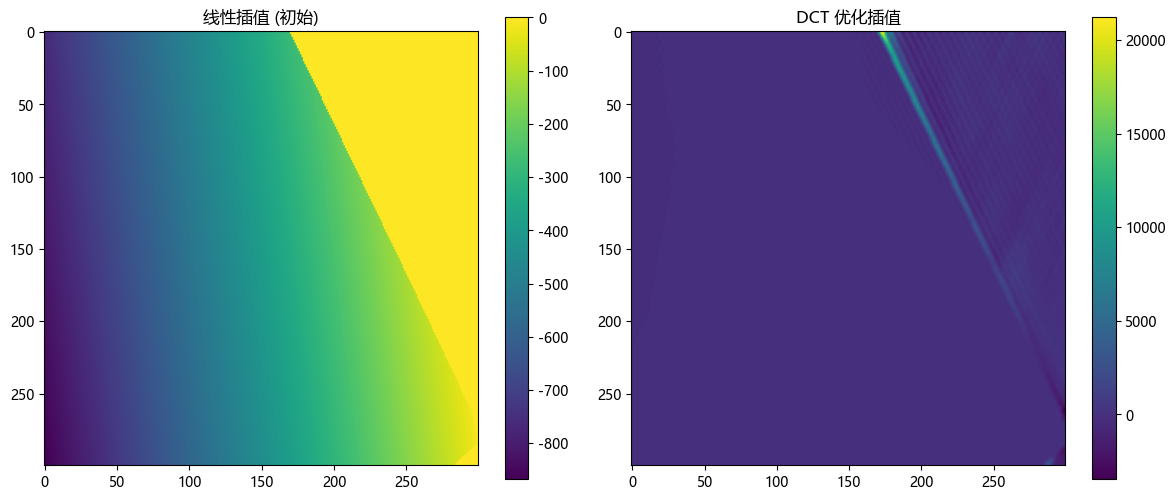

✅ 保存 DCT 插值网格：gridded_surface_dct.npz
✅ 显著波高 Hs: 2.3508 米


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.interpolate
from DCTInterpolator import DCTInterpolator

# === 设置路径 ===
ply_path = r"E:\graduate_design\test7\0820\point_cloud_plane_filtered.ply"
output_dir = r"E:\graduate_design\test7\0824"
os.makedirs(output_dir, exist_ok=True)

# === 加载点云 ===
def load_ply(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    start = lines.index('end_header\n') + 1
    data = np.loadtxt(lines[start:])
    return data[:, :3]

points = load_ply(ply_path)
print(f"✅ 加载点云: {points.shape[0]} 个点")

# === 网格定义 ===
Nx, Ny = 300, 300
xmin, xmax = np.percentile(points[:, 0], [1, 99])
ymin, ymax = np.percentile(points[:, 1], [1, 99])
XX, YY = np.meshgrid(np.linspace(xmin, xmax, Nx), np.linspace(ymin, ymax, Ny))

# === 线性插值初值
ZZ_init = scipy.interpolate.LinearNDInterpolator(points[:, :2], points[:, 2])(XX, YY)

# === DCT插值优化
dct_options = {
    "Nfreqs": 120,
    "MAX_ITERS": 300,
    "TOLERANCE_CHANGE": 1e-4,
    "REGULARIZER_ALPHA": 1e-6,
    "LEARNING_RATE": 4.0
}
dct_interp = DCTInterpolator(img_width=ZZ_init.shape[1], img_height=ZZ_init.shape[0], alg_options=dct_options)
ZZ_dct, _ = dct_interp(ZZ_init)

# === 可视化与保存
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(ZZ_init, cmap='viridis')
plt.title("线性插值 (初始)")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(ZZ_dct, cmap='viridis')
plt.title("DCT 优化插值")
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "gridded_dct_comparison.png"))
plt.show()

np.savez(os.path.join(output_dir, "gridded_surface_dct.npz"), XX=XX, YY=YY, ZZ=ZZ_dct)
print("✅ 保存 DCT 插值网格：gridded_surface_dct.npz")

# === 计算显著波高 Hs
ZZ_valid = ZZ_dct[~np.isnan(ZZ_dct)]/1000.0  # 去除NaN无效值
std_dev = np.std(ZZ_valid)            # 计算标准差
Hs = 4 * std_dev                      # 显著波高 Hs 近似为4倍标准差
print(f"✅ 显著波高 Hs: {Hs:.4f} 米")

✅ 加载点云: 435 个点
Using cpu device
Iter 00000 | Loss: 17897.460938 | Δ: 4.000000
Iter 00050 | Loss: 8222.165039 | Δ: 2082.783936
Iter 00100 | Loss: 2503.210693 | Δ: 2500.000244
Iter 00150 | Loss: 221.611420 | Δ: 2500.000000
Iter 00200 | Loss: 38.882401 | Δ: 1332.751953
Iter 00250 | Loss: 27.410360 | Δ: 678.987061
Iter 00300 | Loss: 21.408524 | Δ: 485.279724


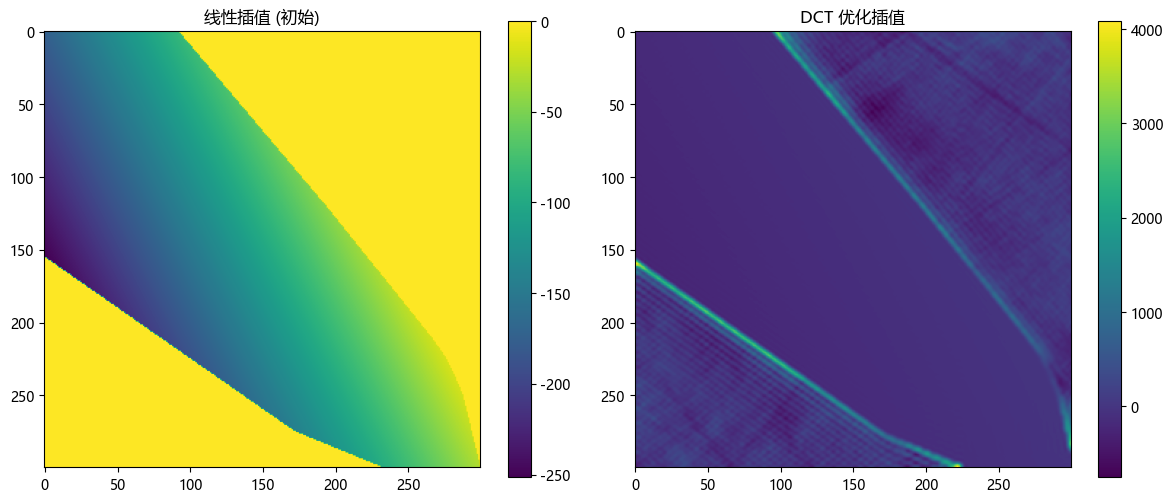

✅ 保存 DCT 插值网格：gridded_surface_dct.npz
✅ 统计结果：
平均值 (Mean): -0.0305 米
中位数 (Median): -0.0873 米
最大值 (Max): 4.0855 米
最小值 (Min): -0.7513 米
第1四分位数 (Q1): -0.1489 米
第3四分位数 (Q3): -0.0090 米
显著波高 (Hs): 1.1128 米
✅ 保存统计结果到 E:\graduate_design\test7\0820\gridded_surface_statistics.txt


In [40]:
import numpy as np 
import matplotlib.pyplot as plt
import os
import scipy.interpolate
from DCTInterpolator import DCTInterpolator

# === 设置路径 ===
ply_path = r"E:\graduate_design\test7\0820\point_cloud_final_filtered.ply"
output_dir = r"E:\graduate_design\test7\0820"
os.makedirs(output_dir, exist_ok=True)

# === 加载点云 ===
def load_ply(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    start = lines.index('end_header\n') + 1
    data = np.loadtxt(lines[start:])
    return data[:, :3]

points = load_ply(ply_path)
print(f"✅ 加载点云: {points.shape[0]} 个点")

# === 网格定义 ===
Nx, Ny = 300, 300
xmin, xmax = np.percentile(points[:, 0], [1, 99])
ymin, ymax = np.percentile(points[:, 1], [1, 99])
XX, YY = np.meshgrid(np.linspace(xmin, xmax, Nx), np.linspace(ymin, ymax, Ny))

# === 线性插值初值
ZZ_init = scipy.interpolate.LinearNDInterpolator(points[:, :2], points[:, 2])(XX, YY)

# === DCT插值优化
dct_options = {
    "Nfreqs": 120,
    "MAX_ITERS": 300,
    "TOLERANCE_CHANGE": 1e-4,
    "REGULARIZER_ALPHA": 1e-6,
    "LEARNING_RATE": 4.0
}
dct_interp = DCTInterpolator(img_width=ZZ_init.shape[1], img_height=ZZ_init.shape[0], alg_options=dct_options)
ZZ_dct, _ = dct_interp(ZZ_init)

# === 可视化与保存
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(ZZ_init, cmap='viridis')
plt.title("线性插值 (初始)")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(ZZ_dct, cmap='viridis')
plt.title("DCT 优化插值")
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "gridded_dct_comparison.png"))
plt.show()

np.savez(os.path.join(output_dir, "gridded_surface_dct.npz"), XX=XX, YY=YY, ZZ=ZZ_dct)
print("✅ 保存 DCT 插值网格：gridded_surface_dct.npz")

# === 计算统计量
ZZ_valid = ZZ_dct[~np.isnan(ZZ_dct)]/1000.0  # 只保留有效值

mean_z = np.mean(ZZ_valid)
median_z = np.median(ZZ_valid)
max_z = np.max(ZZ_valid)
min_z = np.min(ZZ_valid)
q1_z = np.percentile(ZZ_valid, 25)
q3_z = np.percentile(ZZ_valid, 75)
std_dev = np.std(ZZ_valid)
Hs = 4 * std_dev  # 显著波高

# === 打印输出
print(f"✅ 统计结果：")
print(f"平均值 (Mean): {mean_z:.4f} 米")
print(f"中位数 (Median): {median_z:.4f} 米")
print(f"最大值 (Max): {max_z:.4f} 米")
print(f"最小值 (Min): {min_z:.4f} 米")
print(f"第1四分位数 (Q1): {q1_z:.4f} 米")
print(f"第3四分位数 (Q3): {q3_z:.4f} 米")
print(f"显著波高 (Hs): {Hs:.4f} 米")

# === 保存到txt文件
output_stats_path = os.path.join(output_dir, "gridded_surface_statistics.txt")
with open(output_stats_path, 'w') as f:
    f.write("DCT插值后表面统计结果\n")
    f.write(f"平均值 (Mean): {mean_z:.4f} 米\n")
    f.write(f"中位数 (Median): {median_z:.4f} 米\n")
    f.write(f"最大值 (Max): {max_z:.4f} 米\n")
    f.write(f"最小值 (Min): {min_z:.4f} 米\n")
    f.write(f"第1四分位数 (Q1): {q1_z:.4f} 米\n")
    f.write(f"第3四分位数 (Q3): {q3_z:.4f} 米\n")
    f.write(f"显著波高 (Hs): {Hs:.4f} 米\n")
print(f"✅ 保存统计结果到 {output_stats_path}")


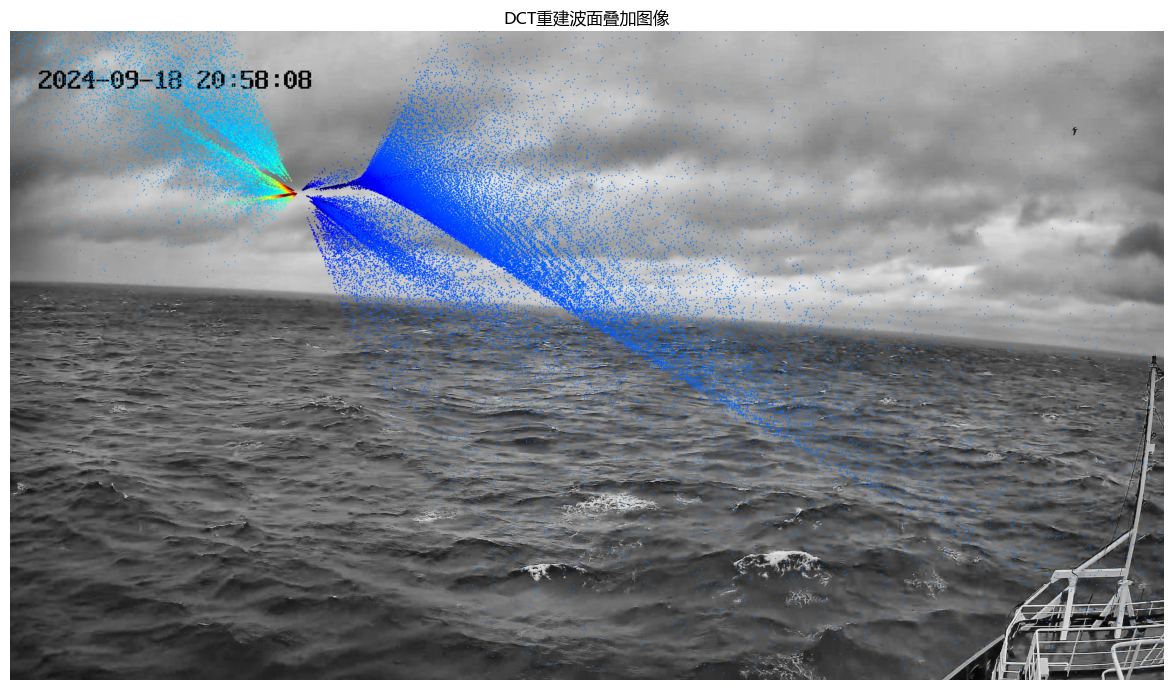

✅ 高程叠加图像已保存至: E:\graduate_design\test4\tmp\test_sequence4\gridding\overlay_on_image.jpg


In [14]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from matplotlib import cm

# === 路径设置 ===
image_path = r"E:\graduate_design\test4\tmp\test_sequence4\output\match1\undistorted_1.jpg"
npz_path = r"E:\graduate_design\test4\tmp\test_sequence4\gridding\gridded_surface_dct.npz"
output_img_path = r"E:\graduate_design\test4\tmp\test_sequence4\gridding\overlay_on_image.jpg"

# === 加载图像和 DCT 插值后的高程数据 ===
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
assert img is not None, "图像加载失败"
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

data = np.load(npz_path)
XX = data["XX"]
YY = data["YY"]
ZZ = data["ZZ"]

# === 设置相机内参（左相机）
K = np.array([
    [1000, 0, 640],
    [0, 1000, 360],
    [0, 0, 1]
], dtype=np.float64)

# === 构造 3D 点
points_3D = np.stack([XX, YY, ZZ], axis=-1).reshape(-1, 3)

# === 将三维点投影到图像平面
points_2D, _ = cv2.projectPoints(points_3D, np.zeros(3), np.zeros(3), K, None)
points_2D = points_2D.reshape(-1, 2)

# === 标准化 ZZ 为 colormap 显示
z_valid = ZZ[~np.isnan(ZZ)]
zmin, zmax = np.percentile(z_valid, [1, 99])
ZZ_norm = (ZZ - zmin) / (zmax - zmin)
ZZ_norm = np.clip(ZZ_norm, 0, 1).reshape(-1)

# === 绘制高程点到图像
for (pt, zval) in zip(points_2D, ZZ_norm):
    u, v = pt
    if np.isnan(u) or np.isnan(v) or np.isnan(zval):
        continue
    if 0 <= int(u) < img.shape[1] and 0 <= int(v) < img.shape[0]:
        rgb = cm.jet(zval)[:3]
        bgr = tuple(int(255 * c) for c in rgb[::-1])
        cv2.circle(img_color, (int(u), int(v)), 1, bgr, -1)

# === 显示图像
plt.figure(figsize=(14, 7))
plt.imshow(img_color[..., ::-1])
plt.title("DCT重建波面叠加图像")
plt.axis("off")
plt.tight_layout()
plt.show()

# === 保存图像
cv2.imwrite(output_img_path, img_color)
print(f"✅ 高程叠加图像已保存至: {output_img_path}")


In [27]:
import numpy as np
import cv2
import os

def read_intrinsics_from_xml(xml_path):
    fs = cv2.FileStorage(xml_path, cv2.FILE_STORAGE_READ)
    K = fs.getNode("intr").mat()  # <<<<<< 正确的节点名称是 intr
    fs.release()
    if K is None or K.shape != (3, 3):
        raise ValueError(f"❌ 无法读取名为 'intr' 的 3x3 相机内参矩阵: {xml_path}")
    print(f"✅ 成功读取相机内参 K：\n{K}")
    return K


def save_camera_ply(workdir, camid, image_name):
    # === 加载相机参数 ===
    K_file = os.path.join(workdir, f"intrinsics_0{camid}.xml")
    R_file = os.path.join(workdir, f"Cam{camid}_poseR.txt")
    T_file = os.path.join(workdir, f"Cam{camid}_poseT.txt")
    img_file = os.path.join(workdir, image_name)

    assert os.path.exists(K_file), f"❌ 找不到内参文件: {K_file}"
    assert os.path.exists(R_file), f"❌ 找不到旋转矩阵文件: {R_file}"
    assert os.path.exists(T_file), f"❌ 找不到平移向量文件: {T_file}"
    assert os.path.exists(img_file), f"❌ 找不到图像: {img_file}"

#     K = read_intrinsics_from_xml(K_file)
#     R = np.loadtxt(R_file)
#     T = np.loadtxt(T_file)
    K = read_intrinsics_from_xml(K_file)
    R = np.loadtxt(R_file).T
    T = np.loadtxt(T_file).reshape(3, 1)


    R = R.T
    T = -R @ T

    I = cv2.imread(img_file)
    H, W = I.shape[:2]

    # === 图像帧角点 ===
    frame_pts = np.array([
        [0, W, W, 0],
        [0, 0, H, H],
        [1, 1, 1, 1]
    ])
    frame_pts_world = R @ np.linalg.inv(K) @ frame_pts + T

    # === 坐标轴 XYZ（单位长度 1，Z轴为 100）===
    axes_pts = np.array([
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 100]
    ])
    axes_pts_world = R @ axes_pts + T

    # === 合并顶点 ===
    verts = np.hstack([axes_pts_world, frame_pts_world]).T

    # === 定义边（X、Y、Z轴 + 图像四边）===
    edges = [
        (0, 1),  # X
        (0, 2),  # Y
        (0, 3),  # Z
        (4, 5), (5, 6), (6, 7), (7, 4)  # image plane
    ]

    # === 输出文件 ===
    ply_path = os.path.join(workdir, f"camera_{camid}.ply")
    with open(ply_path, 'w') as f:
        f.write("ply\nformat ascii 1.0\ncomment camera visualization\n")
        f.write(f"element vertex {len(verts)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write(f"element edge {len(edges)}\n")
        f.write("property int vertex1\nproperty int vertex2\n")
        f.write("end_header\n")
        for v in verts:
            f.write(f"{v[0]} {v[1]} {v[2]}\n")
        for e in edges:
            f.write(f"{e[0]} {e[1]}\n")

    print(f"✅ 已保存相机姿态 PLY：{ply_path}")


In [28]:
save_camera_ply(
    workdir=r"E:\graduate_design\test4\tmp\test_sequence4\output\match1",
    camid=0,
    image_name="00000000_s.png"
)


✅ 成功读取相机内参 K：
[[1.45620366e+03 0.00000000e+00 1.22810331e+03]
 [0.00000000e+00 1.45600476e+03 1.03201102e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
✅ 已保存相机姿态 PLY：E:\graduate_design\test4\tmp\test_sequence4\output\match1\camera_0.ply


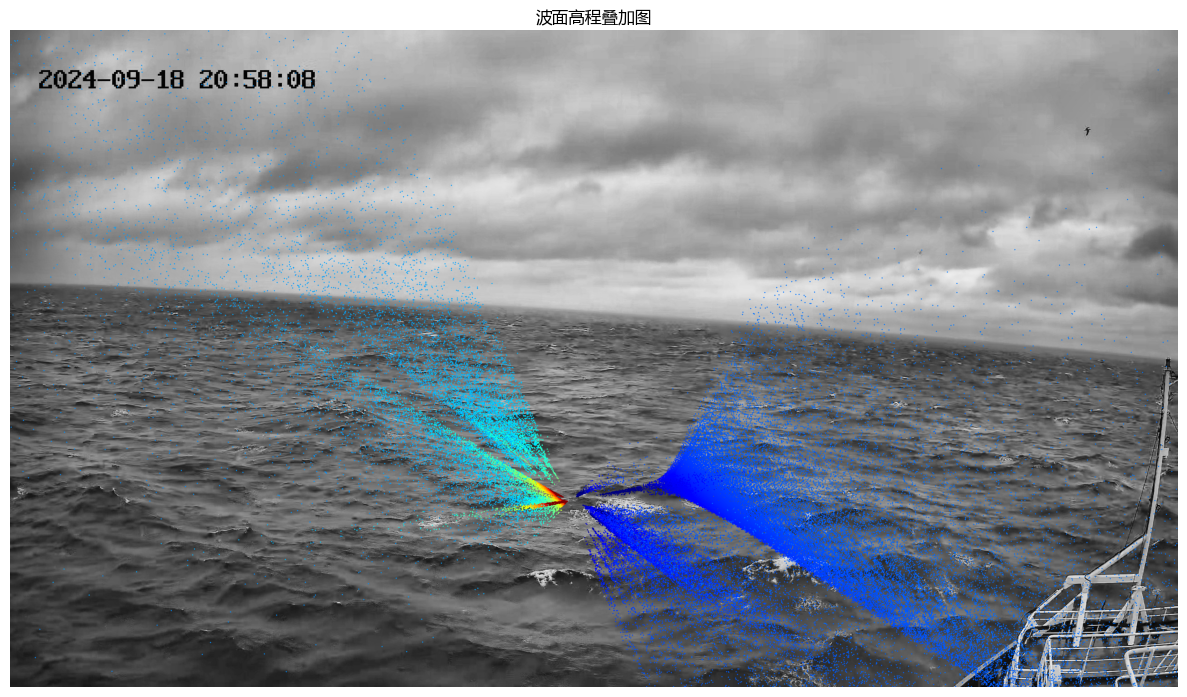

✅ 高度叠加图已保存至：E:\graduate_design\test4\tmp\test_sequence4\gridding\overlay_on_image.jpg


In [29]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import cm
import os

# === 配置路径 ===
img_path = r"E:\graduate_design\test4\tmp\test_sequence4\output\match1\undistorted_1.jpg"
npz_path = r"E:\graduate_design\test4\tmp\test_sequence4\gridding\gridded_surface_dct.npz"
output_path = r"E:\graduate_design\test4\tmp\test_sequence4\gridding\overlay_on_image.jpg"

# === 相机内参（与你实际内参一致）
K = np.array([
    [1456.2, 0, 1228.1],
    [0, 1456.0, 1032.0],
    [0, 0, 1]
])

# === 读取图像 & 网格数据 ===
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
assert img is not None, "图像读取失败"
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

data = np.load(npz_path)
XX = data["XX"]
YY = data["YY"]
ZZ = data["ZZ"]
assert XX.shape == YY.shape == ZZ.shape

# === 将(X, Y, Z)转换为像素(u, v) ===
points_3D = np.stack([XX, YY, ZZ], axis=-1).reshape(-1, 3)
valid_mask = ~np.isnan(points_3D[:, 2])
points_3D = points_3D[valid_mask]

# 视角为相机坐标系原点
rvec = np.zeros(3)
tvec = np.zeros(3)

# 投影为2D像素
points_2D, _ = cv2.projectPoints(points_3D, rvec, tvec, K, None)
points_2D = points_2D.reshape(-1, 2)

# === 对Z进行归一化，并映射颜色 ===
Z_vals = points_3D[:, 2]
Z_min, Z_max = np.percentile(Z_vals, [1, 99])
Z_norm = np.clip((Z_vals - Z_min) / (Z_max - Z_min), 0, 1)
colors = cm.jet(Z_norm)[:, :3]  # RGB

# === 叠加颜色到图像上 ===
for (pt, color) in zip(points_2D, colors):
    u, v = int(pt[0]), int(pt[1])
    if 0 <= u < img.shape[1] and 0 <= v < img.shape[0]:
        bgr = tuple(int(255 * c) for c in color[::-1])  # RGB -> BGR
        cv2.circle(img_color, (u, v), 1, bgr, -1)

# === 显示 & 保存 ===
plt.figure(figsize=(12, 7))
plt.imshow(img_color[..., ::-1])  # BGR -> RGB
plt.title("波面高程叠加图")
plt.axis("off")
plt.tight_layout()
plt.show()

cv2.imwrite(output_path, img_color)
print(f"✅ 高度叠加图已保存至：{output_path}")


In [7]:
# === 在图像上绘制高程点（修复版：排除NaN）
for (coord, zval) in zip(points_2D, ZZ_norm.ravel()):
    u, v = coord
    if np.isnan(u) or np.isnan(v) or np.isnan(zval):
        continue
    if 0 <= int(u) < img.shape[1] and 0 <= int(v) < img.shape[0]:
        color = plt.cm.jet(zval)[:3]
        bgr = tuple(int(255 * c) for c in color[::-1])
        cv2.circle(img_color, (int(u), int(v)), 1, bgr, -1)


D:\py\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\py\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 28010 (\N{CJK UNIFIED IDEOGRAPH-6D6A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\py\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\py\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\py\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 21472 (\N{CJK UNIFIED IDEOGRAPH-53E0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\py\Anaconda3\lib\site-packages\I

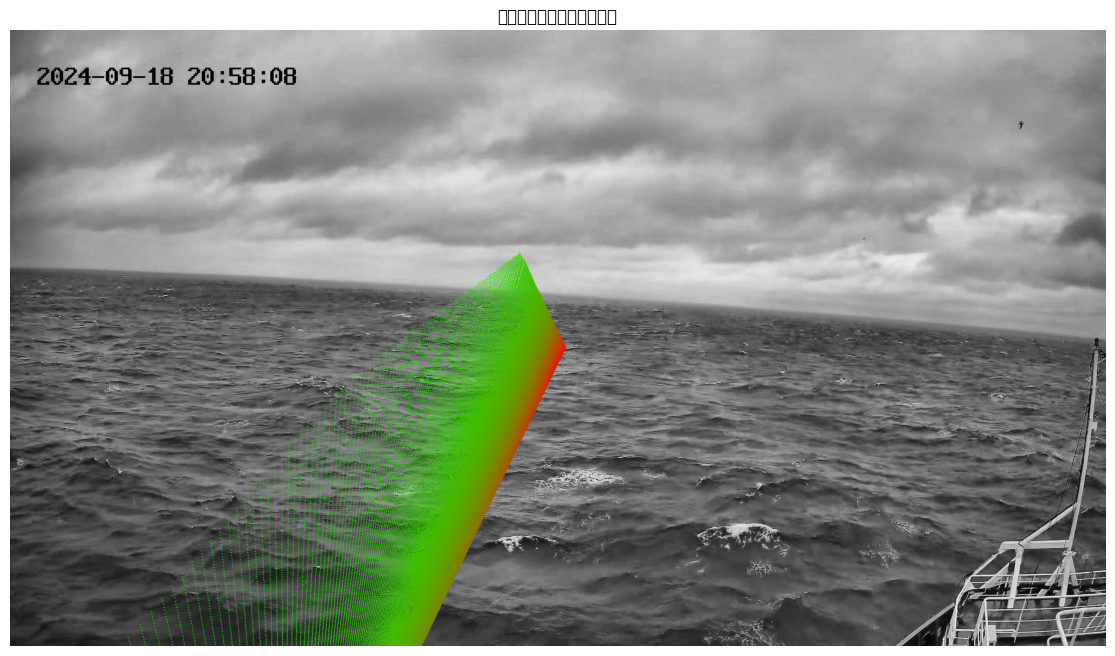

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from netCDF4 import Dataset

# === 路径设定 ===
nc_file = r"E:\graduate_design\test4\tmp\test_sequence4\output\match1\wave_surface.nc"
left_image_path = r"E:\graduate_design\test4\tmp\test_sequence4\output\match1\undistorted_1.jpg"

# 相机内参（你之前设定的 K）
K = np.array([[1000, 0, 640],
              [0, 1000, 360],
              [0, 0, 1]], dtype=np.float64)

# === 读取左图像 ===
img = cv2.imread(left_image_path, cv2.IMREAD_COLOR)
if img is None:
    raise ValueError("❌ 无法读取左图像！")

# === 读取 NetCDF 网格数据 ===
ds = Dataset(nc_file, 'r')
x = ds.variables['x'][:]
y = ds.variables['y'][:]
z = ds.variables['z'][:, :]  # [x, y]

# === 构造 (X, Y, Z) 三维点云 ===
XX, YY = np.meshgrid(x, y)  # 注意顺序：y, x
points_3d = np.stack([XX, YY, z.T], axis=-1).reshape(-1, 3)  # [N, 3]

# === 从世界坐标投影回相机图像平面 ===
# 使用 [R | T] = [I | 0]，因为重建在相机坐标系
rvec = np.zeros((3, 1), dtype=np.float64)
tvec = np.zeros((3, 1), dtype=np.float64)

projected_points, _ = cv2.projectPoints(points_3d, rvec, tvec, K, None)
projected_points = projected_points.reshape(-1, 2)

# === 可视化叠加 ===
img_overlay = img.copy()
for pt, height in zip(projected_points, points_3d[:, 2]):
    if not np.isnan(height):
        color = int(np.clip((height - np.nanmin(z)) / (np.nanmax(z) - np.nanmin(z)) * 255, 0, 255))
        cv2.circle(img_overlay, tuple(np.round(pt).astype(int)), 1, (0, color, 255 - color), -1)

# === 显示结果 ===
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
plt.title("海浪网格叠加在原始图像上")
plt.axis("off")
plt.show()


⚠️ 未在 NetCDF 中找到 RTplane，使用你提供的 opt_R 和 opt_T


D:\py\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 35282 (\N{CJK UNIFIED IDEOGRAPH-89D2}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


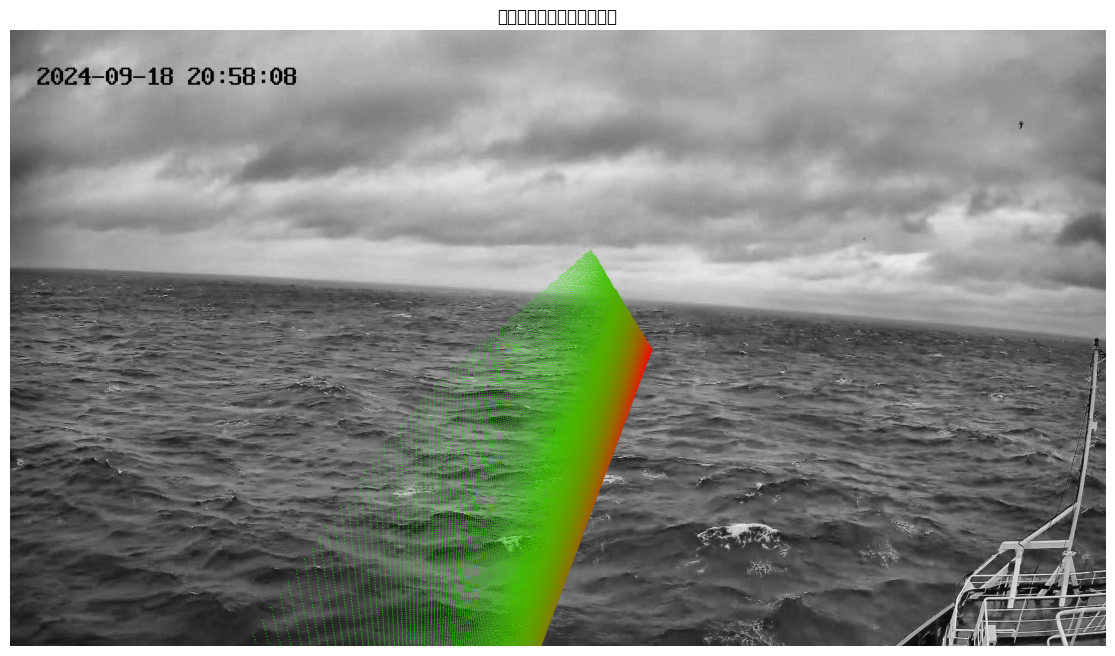

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from netCDF4 import Dataset

# === 设置路径 ===
nc_file = r"E:\graduate_design\test4\tmp\test_sequence4\output\match1\wave_surface.nc"
left_image_path = r"E:\graduate_design\test4\tmp\test_sequence4\output\match1\undistorted_1.jpg"

# === 相机内参矩阵 ===
K = np.array([[1000, 0, 640],
              [0, 1000, 360],
              [0, 0, 1]], dtype=np.float64)

# === 读取图像 ===
img = cv2.imread(left_image_path)
if img is None:
    raise ValueError("❌ 无法读取图像，请检查路径")

# === 读取 NetCDF 网格数据 ===
ds = Dataset(nc_file)
x = ds.variables['x'][:].data
y = ds.variables['y'][:].data
z = ds.variables['z'][:, :].data  # 去除 mask

# 构建网格点并展平
XX, YY = np.meshgrid(x, y)  # shape: (Ny, Nx)
X = XX.flatten()
Y = YY.flatten()
Z = z.T.flatten()  # transpose 后再 flatten 与 X/Y 对齐

# 只保留有效点
valid = ~np.isnan(Z)
points_grid = np.vstack([X[valid], Y[valid], Z[valid], np.ones(np.sum(valid))])  # shape: 4 x N

# === 手动提供优化后的 R 和 T ===
print("⚠️ 未在 NetCDF 中找到 RTplane，使用你提供的 opt_R 和 opt_T")

opt_R = np.array([
    [ 0.99114229,  0.08869916,  0.09884037],
    [-0.09246091,  0.99513078,  0.03414243],
    [-0.09533069, -0.04297888,  0.99451741]
])

opt_T = np.array([[-0.86448489], [0.03300187], [0.19165263]])

# 构建 RTplane（4x4 齐次变换矩阵）
RTplane = np.eye(4)
RTplane[:3, :3] = opt_R
RTplane[:3, 3:] = opt_T

# === 从海面坐标变换到相机坐标系 ===
points_cam = RTplane @ points_grid  # shape: 4 x N
points_cam = points_cam[:3, :].T    # shape: N x 3

# === 投影到图像平面 ===
rvec = np.zeros((3, 1))
tvec = np.zeros((3, 1))
projected, _ = cv2.projectPoints(points_cam, rvec, tvec, K, None)
projected = projected.reshape(-1, 2)

# === 可视化叠加 ===
img_overlay = img.copy()
z_vals = points_cam[:, 2]
z_min, z_max = np.nanmin(z_vals), np.nanmax(z_vals)

for pt, height in zip(projected, z_vals):
    x_img, y_img = int(round(pt[0])), int(round(pt[1]))
    if 0 <= x_img < img.shape[1] and 0 <= y_img < img.shape[0]:
        color_val = int(np.clip((height - z_min) / (z_max - z_min) * 255, 0, 255))
        color = (0, color_val, 255 - color_val)  # 蓝-红渐变
        cv2.circle(img_overlay, (x_img, y_img), 1, color, -1)

# === 显示结果图像 ===
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
plt.title("波浪三维重建贴合图像视角")
plt.axis("off")
plt.show()


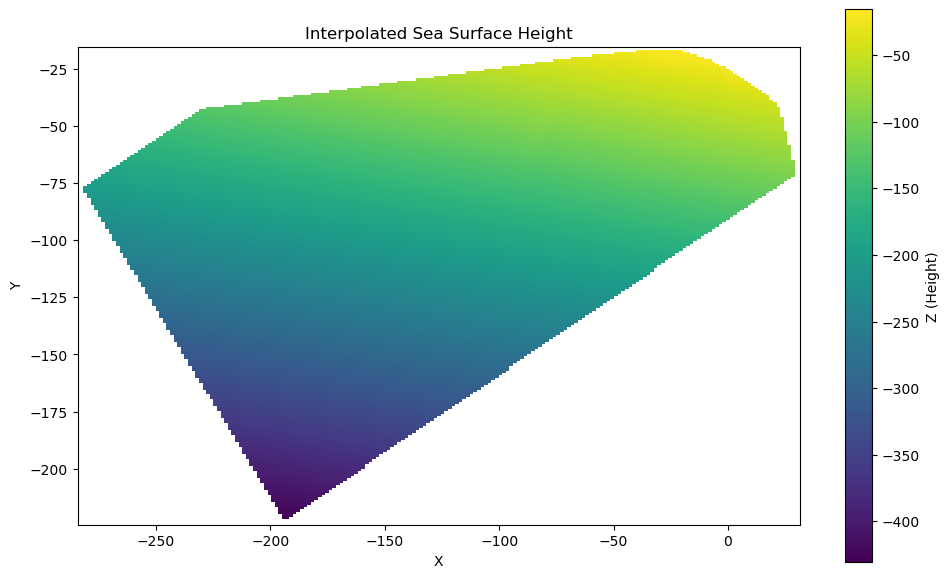

✅ 网格化结果已保存为 NetCDF 文件：E:\graduate_design\test4\tmp\test_sequence4\output\match1\gridded_surface.nc


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from netCDF4 import Dataset
import os

# === 加载上一步保存的点云 ===
ply_file = os.path.join(out_dir, "point_cloud_plane_filtered.ply")
points = []
with open(ply_file, 'r') as f:
    in_header = True
    for line in f:
        if in_header:
            if line.strip() == "end_header":
                in_header = False
            continue
        x, y, z, b, g, r = map(float, line.strip().split())
        points.append((x, y, z))
points = np.array(points)

# === 提取 XYZ 并投影到规则网格 ===
X, Y, Z = points[:, 0], points[:, 1], points[:, 2]
grid_x, grid_y = np.mgrid[X.min():X.max():200j, Y.min():Y.max():200j]  # 200x200 网格
grid_z = griddata((X, Y), Z, (grid_x, grid_y), method='cubic')

# === 可视化网格化后的海面高度 ===
plt.figure(figsize=(10, 6))
plt.imshow(grid_z.T, origin='lower', extent=(X.min(), X.max(), Y.min(), Y.max()), cmap='viridis')
plt.title("Interpolated Sea Surface Height")
plt.colorbar(label="Z (Height)")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()

# === 保存为 NetCDF 文件 ===
ncfile = os.path.join(out_dir, "gridded_surface.nc")
with Dataset(ncfile, 'w', format='NETCDF4') as ds:
    ds.createDimension('x', grid_x.shape[0])
    ds.createDimension('y', grid_x.shape[1])

    xvar = ds.createVariable('x', 'f4', ('x',))
    yvar = ds.createVariable('y', 'f4', ('y',))
    zvar = ds.createVariable('z', 'f4', ('x', 'y',))

    xvar[:] = np.linspace(X.min(), X.max(), grid_x.shape[0])
    yvar[:] = np.linspace(Y.min(), Y.max(), grid_y.shape[1])
    zvar[:, :] = grid_z

    ds.description = "Gridded sea surface height from stereo vision point cloud"
    ds.history = "Created using OpenCV + RANSAC + gridding"
    zvar.units = "meters"

print(f"✅ 网格化结果已保存为 NetCDF 文件：{ncfile}")


✅ 加载点数量: 855


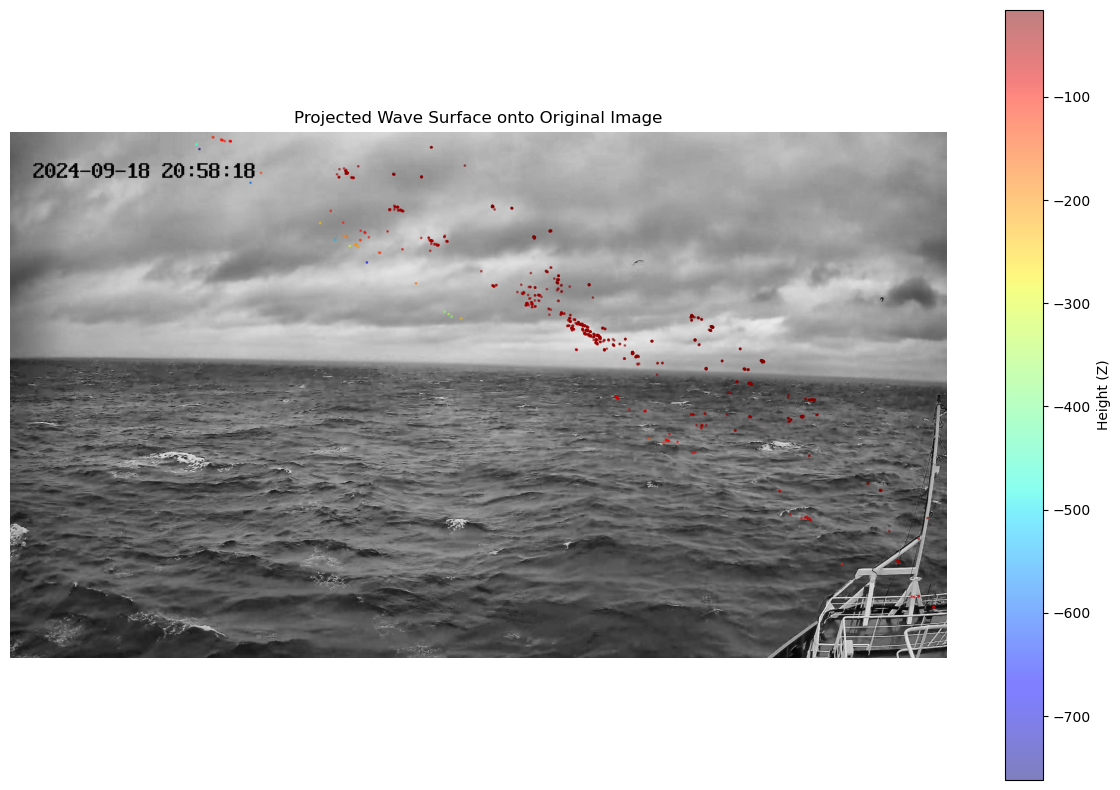

In [17]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# === 设置路径 ===
out_dir = r"E:\graduate_design\test4\tmp\test_sequence4\output"
ply_file = os.path.join(out_dir, "point_cloud_plane_filtered.ply")
img_path = os.path.join(out_dir, "undistorted_1.jpg")

# === 相机参数（替换为你实际使用的） ===
K = np.array([[1000, 0, 640],
              [0, 1000, 360],
              [0, 0, 1]], dtype=np.float64)
opt_R = np.eye(3)  # 替换为你自定义的旋转矩阵
opt_T = np.array([1, 0, 0], dtype=np.float64)  # 替换为你自定义的平移向量

if opt_T.shape == (3,):
    opt_T = opt_T.reshape((3, 1))
P = K @ np.hstack((opt_R, opt_T))  # 投影矩阵 3x4

# === 加载图像 ===
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"图像未找到: {img_path}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# === 读取点云数据 ===
points = []
with open(ply_file, 'r') as f:
    in_header = True
    for line in f:
        if in_header:
            if line.strip() == "end_header":
                in_header = False
            continue
        x, y, z, b, g, r = map(float, line.strip().split())
        points.append((x, y, z))
points = np.array(points)
print("✅ 加载点数量:", points.shape[0])

# === 点云转换为齐次坐标 ===
points_3D = np.hstack((points, np.ones((points.shape[0], 1)))).T  # shape: (4, N)

# === 投影到图像坐标系 ===
pts_2d_h = P @ points_3D  # shape: (3, N)
pts_2d = pts_2d_h[:2, :] / pts_2d_h[2, :]  # 归一化

# === 可视化叠加到图像上 ===
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
sc = plt.scatter(pts_2d[0], pts_2d[1], c=points[:, 2], cmap='jet', s=1, alpha=0.5)
plt.colorbar(sc, label='Height (Z)')
plt.title("Projected Wave Surface onto Original Image")
plt.axis('off')
plt.tight_layout()
plt.show()


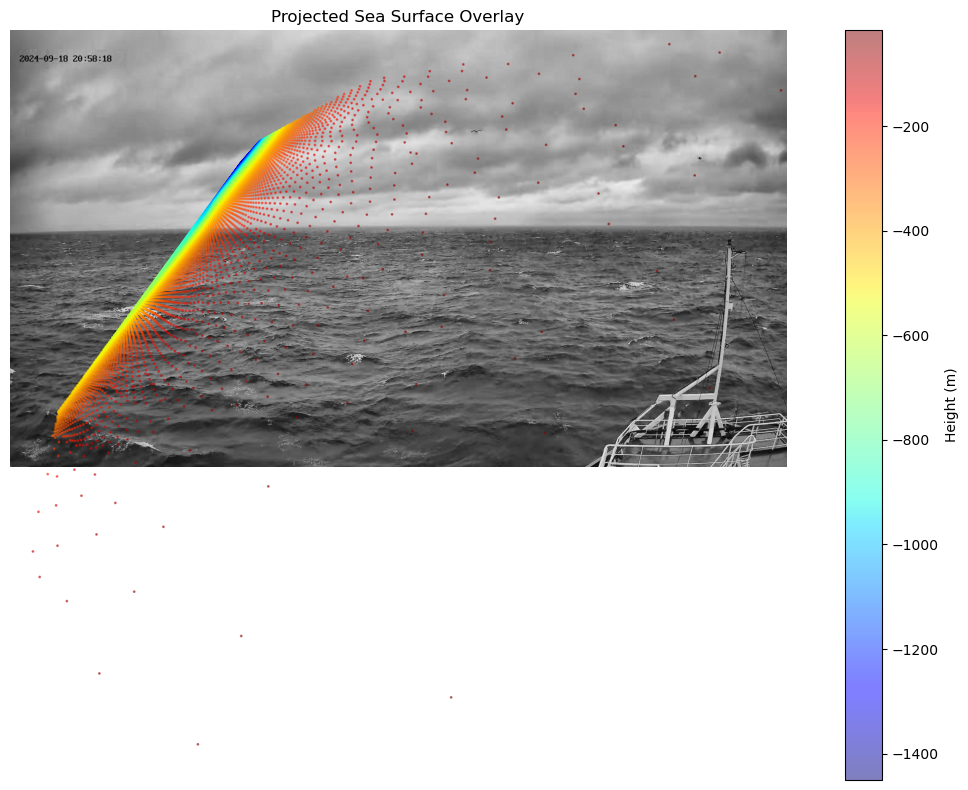

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import cv2
import os

# === 文件路径 ===
out_dir = r"E:\graduate_design\test4\tmp\test_sequence4\output"
nc_path = os.path.join(out_dir, "gridded_surface.nc")
img_path = os.path.join(out_dir, "undistorted_2.jpg")  # 原始图像
P_path = os.path.join(out_dir, "P1cam.txt")            # 投影矩阵

# === 读取图像 ===
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# === 读取 NetCDF 数据 ===
ds = Dataset(nc_path)
x = np.array(ds.variables['x'][:])
y = np.array(ds.variables['y'][:])
z = np.array(ds.variables['z'][:])
ds.close()

# === 清洗 z 为普通 ndarray，构造 meshgrid ===
z = np.array(z)  # 去掉 masked
z[np.isnan(z)] = 0  # 你可以改成更优雅的处理方式
Xg, Yg = np.meshgrid(x, y, indexing='ij')
X_flat = Xg.flatten()
Y_flat = Yg.flatten()
Z_flat = z.flatten()

# 仅保留非零（有效）点
valid_mask = Z_flat != 0
X_valid = X_flat[valid_mask]
Y_valid = Y_flat[valid_mask]
Z_valid = Z_flat[valid_mask]

# === 构造齐次 3D 点 ===
pts_3d = np.stack([X_valid, Y_valid, Z_valid], axis=0)  # (3, N)
pts_3d_h = np.vstack([pts_3d, np.ones((1, pts_3d.shape[1]))])  # (4, N)

# === 加载投影矩阵 P (3x4) ===
# 直接构造 P
K = np.array([[1000, 0, 640],
              [0, 1000, 360],
              [0, 0, 1]], dtype=np.float64)
opt_R = np.eye(3)
opt_T = np.array([[1], [0], [0]])
P = K @ np.hstack((opt_R, opt_T))


# === 投影到图像平面 ===
pts_2d_h = P @ pts_3d_h  # (3, N)
pts_2d = pts_2d_h[:2] / pts_2d_h[2]

# === 叠加绘图 ===
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
sc = plt.scatter(pts_2d[0], pts_2d[1], c=Z_valid, cmap='jet', s=1, alpha=0.5)
plt.colorbar(sc, label="Height (m)")
plt.title("Projected Sea Surface Overlay")
plt.axis('off')
plt.tight_layout()
plt.show()


In [8]:
import math
from collections import Counter

# 去掉空格并统计每个字母的频次
sentence = "Count the number of unique permutations of the alphabetic letters in this sentence excluding spaces."
sentence = sentence.replace(" ", "")  # 去掉空格
letter_counts = Counter(sentence)  # 统计每个字母的频次

# 计算字母总数
N = sum(letter_counts.values())

# 计算排列数
numerator = math.factorial(N)  # 分子是字母总数的阶乘
denominator = 1
for count in letter_counts.values():
    denominator *= math.factorial(count)  # 分母是每个字母频次的阶乘相乘

# 最终排列数
unique_permutations = numerator // denominator
print("唯一排列数:", unique_permutations)


唯一排列数: 124265703314990441352174449283082914435037122553174992772909182978052052421083136000000000000


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from mpl_toolkits.mplot3d import Axes3D

# 读取两张图片
img1_path = r"E:\graduate_design\test2\input\cam0\D02_20240829012415_second_0000.jpg"
img2_path = r"E:\graduate_design\test2\input\cam1\D01_20240829012103_second_0192.jpg"

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

# 检查图片是否成功加载
if img1 is None or img2 is None:
    raise ValueError("图片加载失败，请检查路径是否正确！")

# 转换为灰度图
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 使用SIFT进行特征检测和匹配
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

# 使用FLANN匹配器进行特征匹配
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(descriptors1, descriptors2, k=2)

# 筛选好的匹配点（Lowe's ratio test）
good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

# 获取匹配点的坐标
pts1 = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
pts2 = np.float32([keypoints2[m.trainIdx].pt for m in good_matches])

# 计算基础矩阵和筛选内点
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)
pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

# 立体匹配（假设你已经有了相机参数）
stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)
disparity = stereo.compute(gray1, gray2)

# 三维重建（假设你已经有了相机内参和基线）
focal_length = 1.0  # 焦距
baseline = 1.0  # 基线
Q = np.float32([[1, 0, 0, -gray1.shape[1]/2],
                [0, 1, 0, -gray1.shape[0]/2],
                [0, 0, 0, focal_length],
                [0, 0, -1/baseline, 0]])

points_3D = cv2.reprojectImageTo3D(disparity, Q)

# 提取有效点（去除无效点）
valid_mask = ~np.isinf(points_3D).any(axis=2)
valid_points = points_3D[valid_mask]

# 将三维点投影到二维图像平面
x = valid_points[:, 0]
y = valid_points[:, 1]
z = valid_points[:, 2]

# 使用Delaunay三角剖分生成网格
tri = Delaunay(np.column_stack((x, y)))

# 在原图上绘制网格
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))

# 绘制三角网格
for simplex in tri.simplices:
    pts = np.array([[x[simplex[0]], y[simplex[0]]],
                    [x[simplex[1]], y[simplex[1]]],
                    [x[simplex[2]], y[simplex[2]]]], dtype=np.int32)
    ax.plot(pts[:, 0], pts[:, 1], 'b-', linewidth=0.5)

ax.set_title('Wave 3D Mesh Overlay on Image')
plt.show()

# 可选：绘制三维网格图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(x, y, z, triangles=tri.simplices, cmap='viridis', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Wave Mesh')
plt.show()

D:\py\Anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


D:\py\Anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


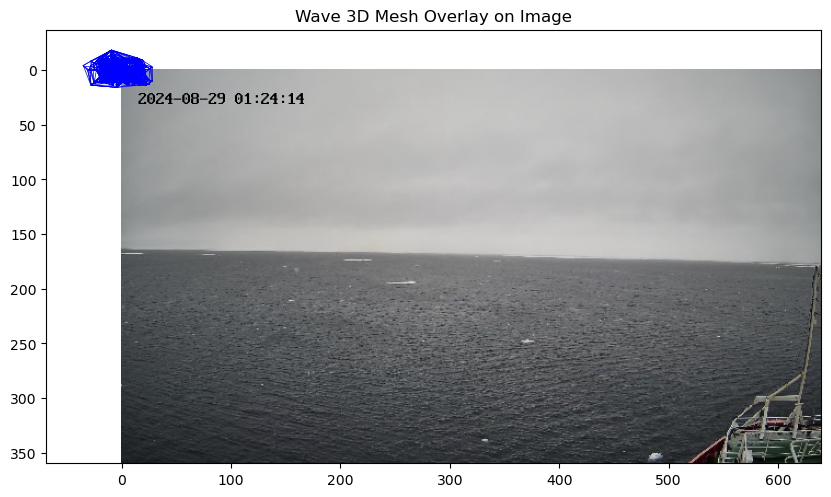

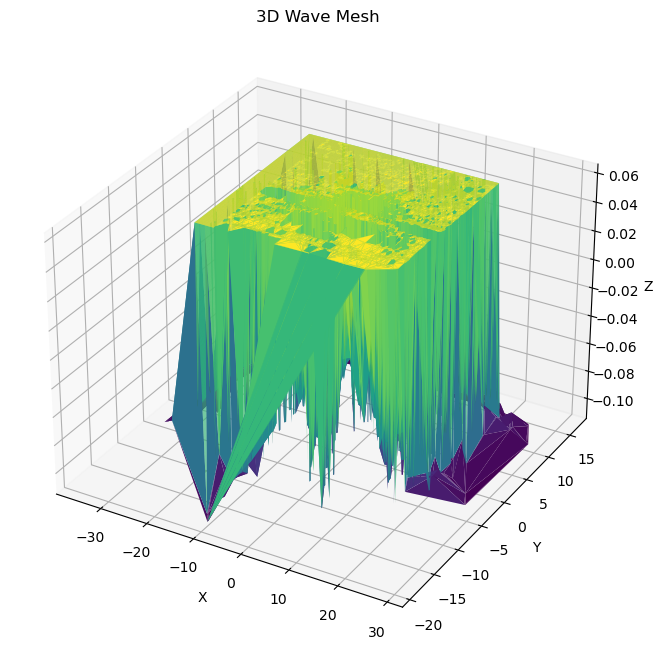

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from mpl_toolkits.mplot3d import Axes3D

# 读取两张图片
img1_path = r"E:\graduate_design\test2\input\cam0\D02_20240829012415_second_0000.jpg"
img2_path = r"E:\graduate_design\test2\input\cam1\D01_20240829012103_second_0192.jpg"

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

# 检查图片是否成功加载
if img1 is None or img2 is None:
    raise ValueError("图片加载失败，请检查路径是否正确！")

# 对图片进行降采样（缩小尺寸）
scale_percent = 25  # 缩小到原来的25%
width = int(img1.shape[1] * scale_percent / 100)
height = int(img1.shape[0] * scale_percent / 100)
img1 = cv2.resize(img1, (width, height))
img2 = cv2.resize(img2, (width, height))

# 转换为灰度图
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 使用ORB进行特征检测和匹配（比SIFT更快）
orb = cv2.ORB_create(nfeatures=1000)  # 限制特征点数量
keypoints1, descriptors1 = orb.detectAndCompute(gray1, None)
keypoints2, descriptors2 = orb.detectAndCompute(gray2, None)

# 使用BFMatcher进行特征匹配（比FLANN更快）
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)

# 筛选好的匹配点（按距离排序）
matches = sorted(matches, key=lambda x: x.distance)
good_matches = matches[:100]  # 只保留前100个最佳匹配点

# 获取匹配点的坐标
pts1 = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
pts2 = np.float32([keypoints2[m.trainIdx].pt for m in good_matches])

# 计算基础矩阵和筛选内点
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)
pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

# 使用SGBM进行立体匹配（比BM更快）
stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=64,  # 减少视差范围
    blockSize=5,        # 减小块大小
    P1=8 * 3 * 5**2,
    P2=32 * 3 * 5**2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32
)
disparity = stereo.compute(gray1, gray2)

# 三维重建（假设你已经有了相机内参和基线）
focal_length = 1.0  # 焦距
baseline = 1.0  # 基线
Q = np.float32([[1, 0, 0, -gray1.shape[1]/2],
                [0, 1, 0, -gray1.shape[0]/2],
                [0, 0, 0, focal_length],
                [0, 0, -1/baseline, 0]])

points_3D = cv2.reprojectImageTo3D(disparity, Q)

# 提取有效点（去除无效点）
valid_mask = ~np.isinf(points_3D).any(axis=2)
valid_points = points_3D[valid_mask]

# 将三维点投影到二维图像平面
x = valid_points[:, 0]
y = valid_points[:, 1]
z = valid_points[:, 2]

# 使用Delaunay三角剖分生成网格
tri = Delaunay(np.column_stack((x, y)))

# 在原图上绘制网格
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))

# 绘制三角网格
for simplex in tri.simplices:
    pts = np.array([[x[simplex[0]], y[simplex[0]]],
                    [x[simplex[1]], y[simplex[1]]],
                    [x[simplex[2]], y[simplex[2]]]], dtype=np.int32)
    ax.plot(pts[:, 0], pts[:, 1], 'b-', linewidth=0.5)

ax.set_title('Wave 3D Mesh Overlay on Image')
plt.show()

# 可选：绘制三维网格图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(x, y, z, triangles=tri.simplices, cmap='viridis', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Wave Mesh')
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from mpl_toolkits.mplot3d import Axes3D

# 读取两张图片
img1_path = r"E:\graduate_design\test2\input\cam0\D02_20240829012415_second_0000.jpg"
img2_path = r"E:\graduate_design\test2\input\cam1\D01_20240829012103_second_0192.jpg"

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

# 检查图片是否成功加载
if img1 is None or img2 is None:
    raise ValueError("图片加载失败，请检查路径是否正确！")

# 转换为灰度图
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 使用SIFT进行特征检测和匹配
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

# 使用FLANN匹配器进行特征匹配
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(descriptors1, descriptors2, k=2)

# 筛选好的匹配点（Lowe's ratio test）
good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

# 获取匹配点的坐标
pts1 = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
pts2 = np.float32([keypoints2[m.trainIdx].pt for m in good_matches])

# 计算基础矩阵和筛选内点
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)
pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

# 立体匹配（假设你已经有了相机参数）
stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)
disparity = stereo.compute(gray1, gray2)

# 三维重建（假设你已经有了相机内参和基线）
focal_length = 1.0  # 焦距
baseline = 1.0  # 基线
Q = np.float32([[1, 0, 0, -gray1.shape[1]/2],
                [0, 1, 0, -gray1.shape[0]/2],
                [0, 0, 0, focal_length],
                [0, 0, -1/baseline, 0]])

points_3D = cv2.reprojectImageTo3D(disparity, Q)

# 提取有效点（去除无效点）
valid_mask = ~np.isinf(points_3D).any(axis=2)
valid_points = points_3D[valid_mask]

# 将三维点投影到二维图像平面
x = valid_points[:, 0]
y = valid_points[:, 1]
z = valid_points[:, 2]

# 使用Delaunay三角剖分生成网格
tri = Delaunay(np.column_stack((x, y)))

# 在原图上绘制网格
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))

# 绘制三角网格
for simplex in tri.simplices:
    pts = np.array([[x[simplex[0]], y[simplex[0]]],
                    [x[simplex[1]], y[simplex[1]]],
                    [x[simplex[2]], y[simplex[2]]]], dtype=np.int32)
    ax.plot(pts[:, 0], pts[:, 1], 'b-', linewidth=0.5)

ax.set_title('Wave 3D Mesh Overlay on Image')
plt.show()

# 可选：绘制三维网格图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(x, y, z, triangles=tri.simplices, cmap='viridis', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Wave Mesh')
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 文件路径
file_path = r"E:\graduate_design\test3\output\000000_wd\mesh_cam.xyzC"

# 读取文件，指定编码为 utf-8
data = np.loadtxt(file_path, encoding='utf-8')

# 提取x, y, z坐标
x = data[:, 0]
y = data[:, 1]
z = data[:, 2]

# 创建3D图形
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 绘制散点图
ax.scatter(x, y, z, c='b', marker='o')

# 设置坐标轴标签
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# 显示图形
plt.show()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xbc in position 0: invalid start byte

NetCDF 数据变量: ['scale', 'time', 'workdir', 'X_grid', 'Y_grid', 'Kx', 'Ky', 'Z', 'maskZ', 'cam0images', 'cam0masks']


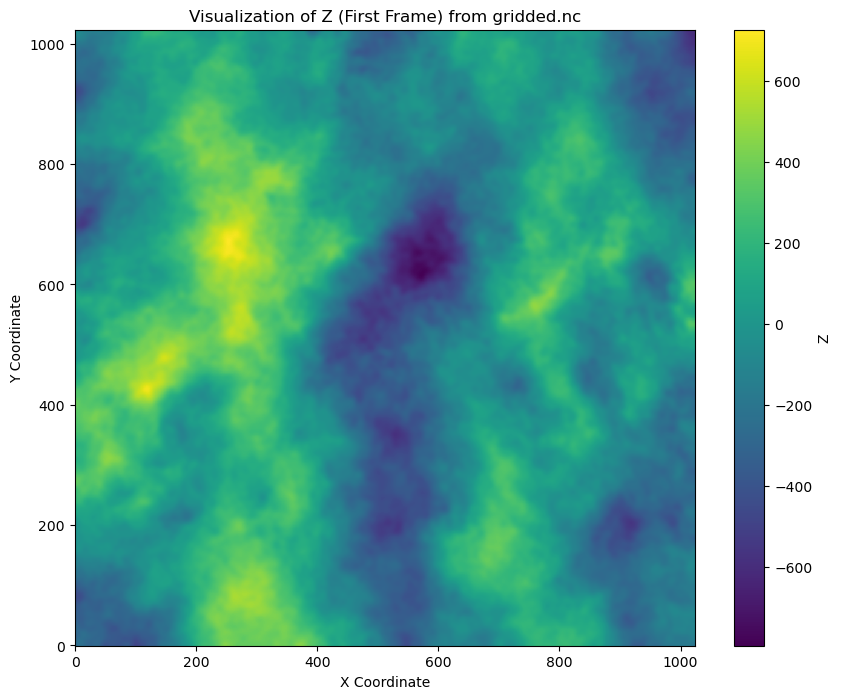

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 文件路径
file_path = r"E:\graduate_design\test3\gridding\gridded.nc"

# 读取 NetCDF 数据
ds = xr.open_dataset(file_path)

# 检查数据变量名称
data_vars = list(ds.data_vars.keys())
print("NetCDF 数据变量:", data_vars)

# 选择变量进行绘制（假设高度数据存储在 'Z' 变量中）
if "Z" in data_vars:
    var_name = "Z"
else:
    var_name = data_vars[0]  # 选择第一个变量作为默认值

Z = ds[var_name].isel(count=0).values  # 仅显示第一帧数据

# 获取坐标
y = ds["Y"].values
x = ds["X"].values

# 创建网格
X, Y = np.meshgrid(x, y)

# 绘制插值后的表面数据
plt.figure(figsize=(10, 8))
plt.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')
plt.colorbar(label=var_name)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title(f"Visualization of {var_name} (First Frame) from gridded.nc")
plt.show()
